# MURA DINOv2 + MLflow training

Self-contained Colab notebook: raw `MURA-v1.1.zip` only, no project scripts.

Flow:
- extract raw MURA;
- build train/internal_val/test frames;
- train DINOv2 transformer with AMP, gradient accumulation, staged unfreezing, checkpoint resume;
- log params, metrics and artifacts to MLflow/MinIO;
- register PRD model in MLflow Model Registry;
- produce baseline, robustness and error-analysis artifacts.


In [ ]:
# Colab/runtime constants. Change these first.
VPS_HOST = "<>"  # example: "203.0.113.10"
# VPS_HOST = "YOUR_VPS_IP"  # example: "203.0.113.10"
MLFLOW_TRACKING_URI = f"http://{VPS_HOST}:8094"
# MLFLOW_TRACKING_URI = f"http://{VPS_HOST}:5050"

# Raw MURA archive. The notebook also checks /content/MURA-v1.1.zip.
MURA_ZIP_PATH = "/content/drive/MyDrive/Project2025/MURA-v1.1.zip"
COPY_ZIP_TO_LOCAL_DISK = True
LOCAL_ZIP_PATH = "/content/MURA-v1.1.zip"

EXPERIMENT_NAME = "project2025-mura-dinov2"
REGISTERED_MODEL_NAME = "mura_dinov2_transformer"
RUN_NAME = "dinov2_transformer_raw_mura"

# Transformer/model settings. Use facebook/dinov2-base if Colab memory is tight.
HF_MODEL_NAME = "facebook/dinov2-large"
IMG_SIZE = 448
EPOCHS = 15
BATCH_SIZE = 32
ACCUM_STEPS = 8
NUM_WORKERS = 2
SEED = 42

HEAD_LR = 3e-4
BACKBONE_LR = 8e-6
WEIGHT_DECAY = 1e-2
CLIP_GRAD_NORM = 1.0
LABEL_SMOOTHING = 0.03
EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 1e-3

# Epoch numbers are 1-based: at epoch 1 only head/classifiers train.
UNFREEZE_SCHEDULE = {
    6: 4,
    9: 8,
    12: 12,
}

USE_AMP = True
RESUME = True
RUN_TRAINING = True
ROBUSTNESS_MAX_IMAGES = 512
ERROR_EXAMPLES = 20

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/Project2025/mlflow_mura_dinov2"
LOCAL_WORK_DIR = "/content/mura_dinov2_work"


In [5]:
# Install notebook dependencies. Restart runtime only if Colab explicitly asks.
%pip -q install "mlflow>=2.15.1,<3" "transformers>=4.45" "accelerate>=0.34" "boto3" "psycopg2-binary" "scikit-learn" "pandas" "matplotlib" "seaborn" "pillow" "tqdm"


In [6]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import sys
import time
import zipfile
from collections import Counter
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import matplotlib.pyplot as plt
import mlflow
import mlflow.pyfunc
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image, ImageEnhance, ImageFilter
from sklearn.metrics import (
    accuracy_score,
    auc,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import AutoModel
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    print("vram_gb:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

WORK_DIR = Path(LOCAL_WORK_DIR)
OUTPUT_DIR = Path(DRIVE_OUTPUT_DIR if IN_COLAB else "mlflow_mura_dinov2")
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
for path in [WORK_DIR, OUTPUT_DIR, ARTIFACT_DIR, CHECKPOINT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print("MLflow tracking URI:", mlflow.get_tracking_uri())


Mounted at /content/drive
device: cuda
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
vram_gb: 102.0
MLflow tracking URI: http://64.226.117.149:8094


In [7]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}


def is_real_image_file(path: Path) -> bool:
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        return False
    if path.name.startswith("._") or path.name == ".DS_Store":
        return False
    if "__MACOSX" in path.parts:
        return False
    return True


BONE_CATEGORIES = [
    "XR_WRIST", "XR_ELBOW", "XR_SHOULDER", "XR_FINGER", "XR_FOREARM", "XR_HUMERUS", "XR_HAND"
]


def resolve_zip_path() -> Path:
    candidates = [Path(MURA_ZIP_PATH), Path(LOCAL_ZIP_PATH), Path("MURA-v1.1.zip")]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "MURA-v1.1.zip not found. Put it at MURA_ZIP_PATH or upload it to /content/MURA-v1.1.zip."
    )


def prepare_zip_for_extraction(zip_path: Path) -> Path:
    local_zip = Path(LOCAL_ZIP_PATH)
    if not COPY_ZIP_TO_LOCAL_DISK:
        return zip_path
    if zip_path.resolve() == local_zip.resolve():
        print("Using local zip:", local_zip)
        return local_zip
    if local_zip.exists() and local_zip.stat().st_size == zip_path.stat().st_size:
        print("Using existing local zip copy:", local_zip)
        return local_zip
    local_zip.parent.mkdir(parents=True, exist_ok=True)
    print(f"Copying MURA zip to local Colab disk: {zip_path} -> {local_zip}")
    start = time.time()
    shutil.copy2(zip_path, local_zip)
    print(f"Copied in {(time.time() - start):.1f}s; size_gb={local_zip.stat().st_size / 1e9:.2f}")
    return local_zip


def extract_mura(zip_path: Path, extract_dir: Path) -> Path:
    marker = extract_dir / ".extracted_mura_v1_1"
    if marker.exists():
        root = find_mura_root(extract_dir)
        print("Using existing extracted MURA:", root)
        return root

    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    print("Extracting", zip_path, "...")
    start = time.time()
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    marker.write_text(str(zip_path))
    root = find_mura_root(extract_dir)
    print(f"Extracted in {(time.time() - start):.1f}s -> {root}")
    return root


def find_mura_root(extract_dir: Path) -> Path:
    candidates = [extract_dir / "MURA-v1.1", extract_dir]
    candidates.extend([p for p in extract_dir.rglob("*") if p.is_dir() and p.name == "MURA-v1.1"])
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "valid").is_dir():
            return candidate
    for candidate in extract_dir.rglob("*"):
        if candidate.is_dir() and (candidate / "train").is_dir() and (candidate / "valid").is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate train/valid under {extract_dir}")


def label_from_path(path: Path) -> int:
    study_name = path.parent.name.lower()
    if "positive" in study_name:
        return 1
    if "negative" in study_name:
        return 0
    raise ValueError(f"Cannot infer label from {path}")


def anatomy_from_path(path: Path) -> str:
    for part in path.parts:
        if part.startswith("XR_"):
            return part
    raise ValueError(f"Cannot infer anatomy from {path}")


def study_from_path(path: Path) -> str:
    # Example: train/XR_HAND/patient10502/study1_positive/image1.png
    parts = path.as_posix().split("/")
    anatomy_index = next(i for i, part in enumerate(parts) if part.startswith("XR_"))
    return "/".join(parts[anatomy_index:anatomy_index + 3])


def build_mura_frame(split_dir: Path, split_name: str) -> pd.DataFrame:
    rows = []
    image_paths = sorted(p for p in split_dir.rglob("*") if p.is_file() and is_real_image_file(p))
    for path in tqdm(image_paths, desc=f"scan {split_name}"):
        rows.append({
            "path": str(path),
            "label": label_from_path(path),
            "anatomy": anatomy_from_path(path),
            "study": study_from_path(path),
            "split_source": split_name,
        })
    if not rows:
        raise RuntimeError(f"No images found in {split_dir}")
    return pd.DataFrame(rows)

zip_path = prepare_zip_for_extraction(resolve_zip_path())
MURA_ROOT = extract_mura(zip_path, WORK_DIR / "mura_extracted")
train_full_df = build_mura_frame(MURA_ROOT / "train", "train")
test_df = build_mura_frame(MURA_ROOT / "valid", "official_valid_as_test")

splitter = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
train_idx, val_idx = next(splitter.split(train_full_df, y=train_full_df["label"], groups=train_full_df["study"]))
train_df = train_full_df.iloc[train_idx].reset_index(drop=True)
val_df = train_full_df.iloc[val_idx].reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

leakage = len(set(train_df.study) & set(val_df.study))
print("train images/studies:", len(train_df), train_df.study.nunique())
print("internal val images/studies:", len(val_df), val_df.study.nunique())
print("test images/studies:", len(test_df), test_df.study.nunique())
print("study leakage:", leakage)
assert leakage == 0

def split_summary(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    by_label = frame.groupby("label").size().rename("images")
    by_anatomy = frame.groupby(["anatomy", "label"]).size().unstack(fill_value=0)
    print("\n", name)
    display(by_label)
    display(by_anatomy)
    return by_anatomy

split_summary(train_df, "train")
split_summary(val_df, "internal_val")
split_summary(test_df, "test")

for name, frame in [("train", train_df), ("internal_val", val_df), ("test", test_df)]:
    frame.to_csv(ARTIFACT_DIR / f"split_{name}.csv", index=False)

summary_rows = []
for name, frame in [("train", train_df), ("internal_val", val_df), ("test", test_df)]:
    summary_rows.append({
        "split": name,
        "images": len(frame),
        "studies": frame.study.nunique(),
        "positive_images": int(frame.label.sum()),
        "negative_images": int((frame.label == 0).sum()),
    })
data_summary_df = pd.DataFrame(summary_rows)
data_summary_df.to_csv(ARTIFACT_DIR / "data_summary.csv", index=False)
display(data_summary_df)


Copying MURA zip to local Colab disk: /content/drive/MyDrive/Project2025/MURA-v1.1.zip -> /content/MURA-v1.1.zip
Copied in 35.6s; size_gb=3.38
Extracting /content/MURA-v1.1.zip ...
Extracted in 8.1s -> /content/mura_dinov2_work/mura_extracted/MURA-v1.1


scan train:   0%|          | 0/36808 [00:00<?, ?it/s]

scan official_valid_as_test:   0%|          | 0/3197 [00:00<?, ?it/s]

train images/studies: 33143 12111
internal val images/studies: 3665 1346
test images/studies: 3197 1199
study leakage: 0

 train


,images
label,
0,19652
1,13491


...

label,0,1
anatomy,,
XR_ELBOW,318,191
XR_FINGER,304,181
XR_FOREARM,138,84
XR_HAND,376,119
XR_HUMERUS,85,57
XR_SHOULDER,446,396
XR_WRIST,616,354



 test


,images
label,
0,1667
1,1530


label,0,1
anatomy,,
XR_ELBOW,235,230
XR_FINGER,214,247
XR_FOREARM,150,151
XR_HAND,271,189
XR_HUMERUS,148,140
XR_SHOULDER,285,278
XR_WRIST,364,295


,split,images,studies,positive_images,negative_images
0,train,33143,12111,13491,19652
1,internal_val,3665,1346,1382,2283
2,test,3197,1199,1530,1667


In [8]:
class SquarePadResize:
    def __init__(self, size: int, fill: int = 0):
        self.size = size
        self.fill = fill

    def __call__(self, image: Image.Image) -> Image.Image:
        image = image.convert("RGB")
        w, h = image.size
        scale = self.size / max(w, h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        image = image.resize((new_w, new_h), Image.BICUBIC)
        canvas = Image.new("RGB", (self.size, self.size), color=(self.fill, self.fill, self.fill))
        canvas.paste(image, ((self.size - new_w) // 2, (self.size - new_h) // 2))
        return canvas

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    SquarePadResize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.94, 1.06), fill=0),
    transforms.ColorJitter(brightness=0.10, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

eval_transform = transforms.Compose([
    SquarePadResize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

class MuraDinoDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform, return_path: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = Image.open(row.path).convert("L")
        image = self.transform(image)
        label = torch.tensor(int(row.label), dtype=torch.long)
        if self.return_path:
            return image, label, row.anatomy, row.study, row.path
        return image, label, row.anatomy, row.study


def seed_worker(worker_id: int) -> None:
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    MuraDinoDataset(train_df, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=loader_generator,
)
val_loader = DataLoader(
    MuraDinoDataset(val_df, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    MuraDinoDataset(test_df, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

xb, yb, ab, sb = next(iter(train_loader))
print(xb.shape, yb.shape, list(ab)[:3], list(sb)[:3])


torch.Size([32, 3, 448, 448]) torch.Size([32]) ['XR_ELBOW', 'XR_WRIST', 'XR_ELBOW'] ['XR_ELBOW/patient05777/study1_negative', 'XR_WRIST/patient07052/study1_positive', 'XR_ELBOW/patient05452/study1_positive']


In [9]:
class MuraDinoClassifier(nn.Module):
    def __init__(self, model_name: str, bone_categories: list[str], dropout: float = 0.30):
        super().__init__()
        self.model_name = model_name
        self.bone_categories = list(bone_categories)
        self.dino = AutoModel.from_pretrained(model_name)
        hidden_size = int(self.dino.config.hidden_size)
        self.feature_dim = hidden_size * 2
        self.head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.20),
        )
        self.classifiers = nn.ModuleDict({bone: nn.Linear(128, 2) for bone in self.bone_categories})
        self.freeze_backbone()

    def freeze_backbone(self) -> None:
        for p in self.dino.parameters():
            p.requires_grad = False

    def transformer_layers(self):
        if hasattr(self.dino, "encoder") and hasattr(self.dino.encoder, "layer"):
            return list(self.dino.encoder.layer)
        raise AttributeError("Unsupported DINO backbone: cannot find dino.encoder.layer")

    def set_trainable_last_n_blocks(self, n_blocks: int) -> None:
        self.freeze_backbone()
        if n_blocks <= 0:
            return
        layers = self.transformer_layers()
        for layer in layers[-n_blocks:]:
            for p in layer.parameters():
                p.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        outputs = self.dino(pixel_values=x)
        tokens = outputs.last_hidden_state
        cls_token = tokens[:, 0, :]
        patch_mean = tokens[:, 1:, :].mean(dim=1)
        return self.head(torch.cat([cls_token, patch_mean], dim=1))

    def forward(self, x: torch.Tensor, anatomies) -> torch.Tensor:
        feat = self.forward_features(x)
        logits = torch.empty((x.size(0), 2), dtype=feat.dtype, device=feat.device)
        anatomies = list(anatomies)
        for bone in sorted(set(anatomies)):
            idx = [i for i, value in enumerate(anatomies) if value == bone]
            idx_t = torch.tensor(idx, dtype=torch.long, device=feat.device)
            logits[idx_t] = self.classifiers[bone](feat[idx_t])
        return logits


def trainable_param_count(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def total_param_count(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def n_unfrozen_blocks_for_epoch(epoch: int) -> int:
    n = 0
    for start_epoch, blocks in sorted(UNFREEZE_SCHEDULE.items()):
        if epoch >= start_epoch:
            n = int(blocks)
    return n


def configure_trainable(model: MuraDinoClassifier, epoch: int) -> int:
    n_blocks = n_unfrozen_blocks_for_epoch(epoch)
    model.set_trainable_last_n_blocks(n_blocks)
    for p in model.head.parameters():
        p.requires_grad = True
    for p in model.classifiers.parameters():
        p.requires_grad = True
    return n_blocks


def make_optimizer(model: MuraDinoClassifier) -> torch.optim.Optimizer:
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("dino."):
            backbone_params.append(param)
        else:
            head_params.append(param)
    groups = []
    if backbone_params:
        groups.append({"params": backbone_params, "lr": BACKBONE_LR, "name": "backbone"})
    if head_params:
        groups.append({"params": head_params, "lr": HEAD_LR, "name": "head"})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)


def lr_summary(optimizer) -> str:
    return ", ".join(f"{g.get('name', i)}={g['lr']:.2e}" for i, g in enumerate(optimizer.param_groups))


def pr_auc_score(y_true, y_prob) -> float:
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    return float(auc(recall, precision))


def binary_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(np.int64)
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "kappa": float(cohen_kappa_score(y_true, y_pred)),
    }
    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
        out["pr_auc"] = pr_auc_score(y_true, y_prob)
    else:
        out["roc_auc"] = float("nan")
        out["pr_auc"] = float("nan")
    out["composite"] = 0.3 * out["kappa"] + 0.5 * out["pr_auc"] + 0.2 * out["roc_auc"]
    return out


def metrics_by_anatomy(pred_df: pd.DataFrame, threshold: float = 0.5) -> dict:
    out = {}
    for anatomy, part in pred_df.groupby("anatomy"):
        out[anatomy] = binary_metrics(part.label.values, part.prob.values, threshold=threshold)
    return out


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, epoch: int = 0, desc: str = ""):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_items = 0
    all_labels, all_probs, all_anatomies, all_studies = [], [], [], []

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    iterator = tqdm(loader, desc=desc, leave=False)
    for step, batch in enumerate(iterator, start=1):
        images, labels, anatomies, studies = batch
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP and DEVICE.type == "cuda"):
                logits = model(images, anatomies)
                loss = criterion(logits.float(), labels)
                step_loss = loss / ACCUM_STEPS if is_train else loss

            if is_train:
                scaler.scale(step_loss).backward()
                if step % ACCUM_STEPS == 0 or step == len(loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], CLIP_GRAD_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

        probs = torch.softmax(logits.detach().float(), dim=1)[:, 1]
        bs = images.size(0)
        total_loss += float(loss.detach().item()) * bs
        total_items += bs
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_anatomies.extend(list(anatomies))
        all_studies.extend(list(studies))
        iterator.set_postfix(loss=total_loss / max(total_items, 1))

    pred_df = pd.DataFrame({
        "label": all_labels,
        "prob": all_probs,
        "anatomy": all_anatomies,
        "study": all_studies,
    })
    metrics = binary_metrics(pred_df.label.values, pred_df.prob.values)
    metrics["loss"] = total_loss / max(total_items, 1)
    return metrics, pred_df


def predict_frame(model, frame: pd.DataFrame, loader: DataLoader, split_name: str) -> pd.DataFrame:
    model.eval()
    rows = []
    offset = 0
    with torch.inference_mode():
        for images, labels, anatomies, studies in tqdm(loader, desc=f"predict {split_name}"):
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images, anatomies)
            probs = torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
            bs = len(labels)
            part = frame.iloc[offset: offset + bs].copy().reset_index(drop=True)
            part["prob"] = probs
            part["pred"] = (part["prob"] >= 0.5).astype(int)
            rows.append(part)
            offset += bs
    return pd.concat(rows, ignore_index=True)


def aggregate_study_predictions(image_pred_df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    study_df = (
        image_pred_df.groupby("study", as_index=False)
        .agg(label=("label", "first"), anatomy=("anatomy", "first"), n_images=("path", "size"), prob=("prob", "mean"))
    )
    study_df["pred"] = (study_df.prob >= threshold).astype(int)
    return study_df


def find_best_threshold(study_pred_df: pd.DataFrame) -> tuple[float, pd.DataFrame]:
    rows = []
    best_t, best_k = 0.5, -999.0
    for threshold in np.linspace(0.10, 0.90, 81):
        pred = (study_pred_df.prob.values >= threshold).astype(int)
        kappa = cohen_kappa_score(study_pred_df.label.values, pred)
        rows.append({"threshold": float(threshold), "study_kappa": float(kappa)})
        if kappa > best_k:
            best_t, best_k = float(threshold), float(kappa)
    return best_t, pd.DataFrame(rows)


def save_checkpoint(path: Path, model, optimizer, scheduler, scaler, epoch: int, best_metric: float, history: list[dict], n_blocks: int) -> None:
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "best_metric": best_metric,
        "history": history,
        "n_unfrozen_blocks": n_blocks,
        "config": training_config(),
    }, path)


def load_checkpoint(path: Path, model, optimizer=None, scheduler=None, scaler=None) -> dict:
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and ckpt.get("optimizer_state") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt


def training_config() -> dict:
    return {
        "hf_model_name": HF_MODEL_NAME,
        "img_size": IMG_SIZE,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "accum_steps": ACCUM_STEPS,
        "effective_batch_size": BATCH_SIZE * ACCUM_STEPS,
        "num_workers": NUM_WORKERS,
        "seed": SEED,
        "head_lr": HEAD_LR,
        "backbone_lr": BACKBONE_LR,
        "weight_decay": WEIGHT_DECAY,
        "clip_grad_norm": CLIP_GRAD_NORM,
        "label_smoothing": LABEL_SMOOTHING,
        "unfreeze_schedule": UNFREEZE_SCHEDULE,
        "bone_categories": BONE_CATEGORIES,
        "mura_zip_name": Path(zip_path).name,
        "mura_root": str(MURA_ROOT),
    }

print("Training utilities ready")


Training utilities ready


In [10]:
client = MlflowClient()
existing_exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if existing_exp is None:
    EXPERIMENT_ID = client.create_experiment(EXPERIMENT_NAME, artifact_location="mlflow-artifacts:/")
else:
    EXPERIMENT_ID = existing_exp.experiment_id
mlflow.set_experiment(EXPERIMENT_NAME)
print("experiment_id:", EXPERIMENT_ID)

model = MuraDinoClassifier(HF_MODEL_NAME, BONE_CATEGORIES).to(DEVICE)
print("total params M:", round(total_param_count(model) / 1e6, 1))

pos = int(train_df.label.sum())
neg = int((train_df.label == 0).sum())
class_weights = torch.tensor([1.0, neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

last_ckpt_path = CHECKPOINT_DIR / "last.pt"
best_ckpt_path = CHECKPOINT_DIR / "best.pt"
history_path = ARTIFACT_DIR / "training_history.csv"
config_path = ARTIFACT_DIR / "training_config.json"
config_path.write_text(json.dumps(training_config(), indent=2, ensure_ascii=False))

history = []
best_metric = -999.0
start_epoch = 1
optimizer = None
scheduler = None
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and DEVICE.type == "cuda")
current_blocks = None

if RESUME and last_ckpt_path.exists():
    temp_epoch = int(torch.load(last_ckpt_path, map_location="cpu").get("epoch", 0))
    start_epoch = temp_epoch + 1
    current_blocks = configure_trainable(model, max(temp_epoch, 1))
    optimizer = make_optimizer(model)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
    ckpt = load_checkpoint(last_ckpt_path, model, optimizer, scheduler, scaler)
    history = list(ckpt.get("history", []))
    best_metric = float(ckpt.get("best_metric", -999.0))
    print(f"Resumed from epoch {temp_epoch}; next epoch {start_epoch}; best_metric={best_metric:.4f}")

params_to_log = training_config() | {
    "pos_weight_ce": float(class_weights[1].item()),
    "train_images": len(train_df),
    "internal_val_images": len(val_df),
    "test_images": len(test_df),
    "train_studies": train_df.study.nunique(),
    "internal_val_studies": val_df.study.nunique(),
    "test_studies": test_df.study.nunique(),
}

if RUN_TRAINING:
    with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=RUN_NAME) as run:
        RUN_ID = run.info.run_id
        print("run_id:", RUN_ID)
        mlflow.set_tags({
            "task": "mura_binary_abnormality",
            "model_family": "dinov2",
            "data": "raw MURA-v1.1.zip",
            "env": "training",
        })
        mlflow.log_params({k: str(v) if isinstance(v, (dict, list)) else v for k, v in params_to_log.items()})
        mlflow.log_artifacts(str(ARTIFACT_DIR), artifact_path="setup")

        early_counter = 0
        for epoch in range(start_epoch, EPOCHS + 1):
            epoch_start = time.time()
            n_blocks = configure_trainable(model, epoch)
            if optimizer is None or current_blocks != n_blocks:
                optimizer = make_optimizer(model)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
                current_blocks = n_blocks
                print(f"epoch {epoch}: configured trainable DINO blocks = {n_blocks}")

            train_metrics, _ = run_epoch(
                model, train_loader, criterion, optimizer=optimizer, scaler=scaler, epoch=epoch, desc=f"train {epoch}"
            )
            val_metrics, val_epoch_pred_df = run_epoch(
                model, val_loader, criterion, optimizer=None, scaler=None, epoch=epoch, desc=f"val {epoch}"
            )
            scheduler.step(val_metrics["composite"])

            elapsed_min = (time.time() - epoch_start) / 60
            row = {
                "epoch": epoch,
                "elapsed_min": elapsed_min,
                "n_unfrozen_blocks": n_blocks,
                "trainable_params": trainable_param_count(model),
                "lr_groups": lr_summary(optimizer),
            }
            row.update({f"train_{k}": v for k, v in train_metrics.items()})
            row.update({f"val_{k}": v for k, v in val_metrics.items()})
            history.append(row)
            history_df = pd.DataFrame(history)
            history_df.to_csv(history_path, index=False)

            mlflow.log_metrics({f"train/{k}": float(v) for k, v in train_metrics.items()}, step=epoch)
            mlflow.log_metrics({f"val/{k}": float(v) for k, v in val_metrics.items()}, step=epoch)
            mlflow.log_metrics({
                "trainable_params": float(trainable_param_count(model)),
                "n_unfrozen_blocks": float(n_blocks),
                "epoch_elapsed_min": float(elapsed_min),
            }, step=epoch)
            for anatomy, metrics in metrics_by_anatomy(val_epoch_pred_df).items():
                mlflow.log_metrics({f"val_by_anatomy/{anatomy}_{k}": float(v) for k, v in metrics.items()}, step=epoch)

            improved = val_metrics["composite"] > best_metric + EARLY_STOP_MIN_DELTA
            if improved:
                best_metric = val_metrics["composite"]
                early_counter = 0
                save_checkpoint(best_ckpt_path, model, optimizer, scheduler, scaler, epoch, best_metric, history, n_blocks)
                print(f"epoch {epoch}: new best composite={best_metric:.4f}")
            else:
                early_counter += 1

            save_checkpoint(last_ckpt_path, model, optimizer, scheduler, scaler, epoch, best_metric, history, n_blocks)
            print(
                f"epoch {epoch:02d}/{EPOCHS} | "
                f"train loss={train_metrics['loss']:.4f} kappa={train_metrics['kappa']:.4f} "
                f"val loss={val_metrics['loss']:.4f} kappa={val_metrics['kappa']:.4f} "
                f"val composite={val_metrics['composite']:.4f} | {lr_summary(optimizer)} | {elapsed_min:.1f}m"
            )

            if early_counter >= EARLY_STOP_PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        mlflow.log_artifact(str(history_path), artifact_path="training")
        mlflow.log_artifact(str(last_ckpt_path), artifact_path="checkpoints")
        mlflow.log_artifact(str(best_ckpt_path), artifact_path="checkpoints")
else:
    RUN_ID = None
    print("RUN_TRAINING=False; skipping training")


experiment_id: 1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

...

epoch 14: new best composite=0.8116
epoch 14/15 | train loss=0.3121 kappa=0.7755 val loss=0.4533 kappa=0.6758 val composite=0.8116 | backbone=8.00e-06, head=3.00e-04 | 5.1m


train 15:   0%|          | 0/1036 [00:00<?, ?it/s]

val 15:   0%|          | 0/115 [00:00<?, ?it/s]

epoch 15/15 | train loss=0.2862 kappa=0.8016 val loss=0.4487 kappa=0.6754 val composite=0.8091 | backbone=8.00e-06, head=3.00e-04 | 5.1m
🏃 View run dinov2_transformer_raw_mura at: http://64.226.117.149:8094/#/experiments/1/runs/881e12663a1f47ad92782a3747339baa
🧪 View experiment at: http://64.226.117.149:8094/#/experiments/1


MlflowException: API request to http://64.226.117.149:8094/api/2.0/mlflow-artifacts/artifacts/881e12663a1f47ad92782a3747339baa/artifacts/checkpoints/last.pt failed with exception HTTPConnectionPool(host='64.226.117.149', port=8094): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/881e12663a1f47ad92782a3747339baa/artifacts/checkpoints/last.pt (Caused by ResponseError('too many 500 error responses'))

In [12]:
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=RUN_NAME) as run:
  mlflow.log_artifact(str(last_ckpt_path), artifact_path="checkpoints")


🏃 View run dinov2_transformer_raw_mura at: http://64.226.117.149:8094/#/experiments/1/runs/bf7cd2991ce14f819f4392dceb5fc963
🧪 View experiment at: http://64.226.117.149:8094/#/experiments/1


KeyboardInterrupt: 

loaded best checkpoint from epoch 14


predict train:   0%|          | 0/1036 [00:00<?, ?it/s]

predict internal_val:   0%|          | 0/115 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cd656daeb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^^^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7cd656daeb60>^^
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
AssertionError    : assert self._parent_pid == os.getpid(), 'can only test a child process

predict test:   0%|          | 0/100 [00:00<?, ?it/s]

best internal_val study threshold: 0.51


,split,level,threshold,accuracy,precision,recall,f1,kappa,roc_auc,pr_auc,composite,anatomy
0,train,image,0.51,0.914462,0.908276,0.878586,0.893184,0.821887,0.968675,0.963845,0.922224,NaN
1,train,study,0.51,0.938816,0.941637,0.897676,0.919131,0.869970,0.980294,0.975590,0.944845,NaN
2,train,study,0.51,0.951654,0.977901,0.892437,0.933216,0.895454,0.985521,0.983275,0.957378,XR_ELBOW
3,train,study,0.51,0.946316,0.941799,0.897479,0.919105,0.878969,0.983731,0.975310,0.948092,XR_FINGER
4,train,study,0.51,0.957254,0.954167,0.912351,0.932790,0.901474,0.992085,0.986759,0.962239,XR_FOREARM
5,train,study,0.51,0.919935,0.934383,0.744770,0.828871,0.777480,0.945887,0.912511,0.878677,XR_HAND
6,train,study,0.51,0.984704,0.979592,0.987654,0.983607,0.969270,0.998648,0.998523,0.989772,XR_HUMERUS
7,train,study,0.51,0.931658,0.919649,0.951625,0.935364,0.862909,0.981697,0.984854,0.947639,XR_SHOULDER
8,train,study,0.51,0.932819,0.942325,0.880597,0.910416,0.856773,0.980381,0.974701,0.940458,XR_WRIST
9,internal_val,image,0.51,0.849113,0.801894,0.796671,0.799274,0.678402,0.891970,0.860769,0.812299,NaN


,baseline,split,level,accuracy,f1,kappa,roc_auc
0,global_majority,test,study,0.551293,0.000000,0.000000,NaN
1,anatomy_majority,test,study,0.547957,0.259563,0.028502,0.51982


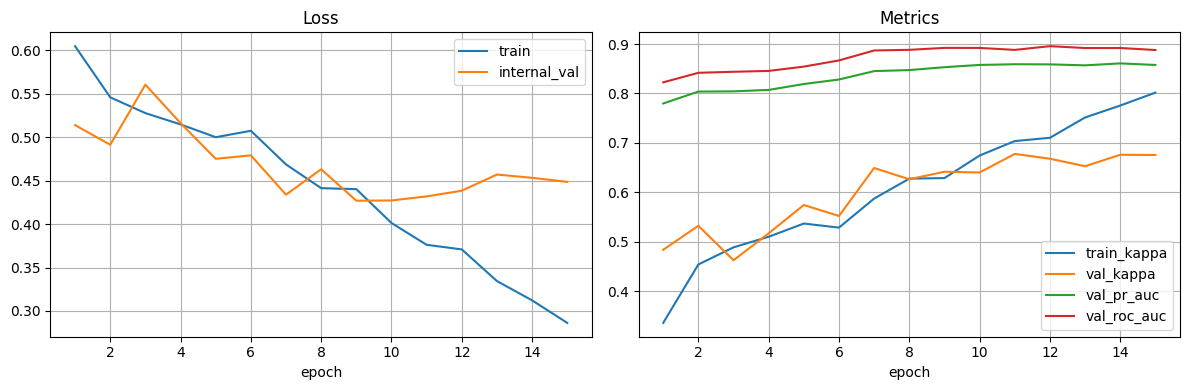

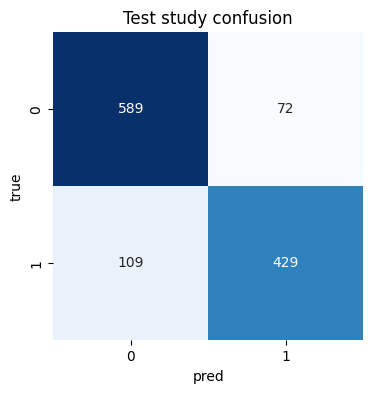

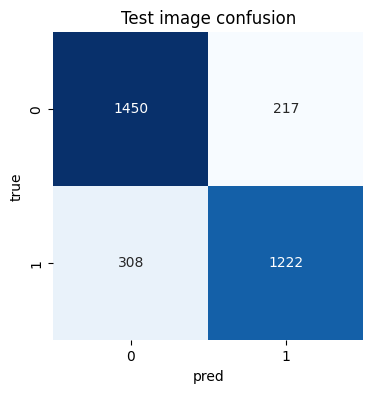

In [13]:
# Load best checkpoint for all final analyses.
if best_ckpt_path.exists():
    best_meta = torch.load(best_ckpt_path, map_location=DEVICE)
    configure_trainable(model, max(int(best_meta.get("epoch", 1)), 1))
    model.load_state_dict(best_meta["model_state"])
    best_epoch = int(best_meta.get("epoch", -1))
    print("loaded best checkpoint from epoch", best_epoch)
else:
    print("best checkpoint not found; using current model state")

model.eval()
train_pred_img = predict_frame(model, train_df, DataLoader(MuraDinoDataset(train_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS), "train")
val_pred_img = predict_frame(model, val_df, val_loader, "internal_val")
test_pred_img = predict_frame(model, test_df, test_loader, "test")

val_study_05 = aggregate_study_predictions(val_pred_img, threshold=0.5)
best_threshold, threshold_df = find_best_threshold(val_study_05)
print("best internal_val study threshold:", best_threshold)
threshold_df.to_csv(ARTIFACT_DIR / "threshold_search_internal_val.csv", index=False)

final_rows = []
study_prediction_frames = {}
image_prediction_frames = {"train": train_pred_img, "internal_val": val_pred_img, "test": test_pred_img}
for split_name, image_df in image_prediction_frames.items():
    image_df = image_df.copy()
    image_df["pred"] = (image_df.prob >= best_threshold).astype(int)
    image_df.to_csv(ARTIFACT_DIR / f"{split_name}_image_predictions.csv", index=False)

    image_metrics = binary_metrics(image_df.label.values, image_df.prob.values, threshold=best_threshold)
    final_rows.append({"split": split_name, "level": "image", "threshold": best_threshold, **image_metrics})

    study_df = aggregate_study_predictions(image_df, threshold=best_threshold)
    study_prediction_frames[split_name] = study_df
    study_df.to_csv(ARTIFACT_DIR / f"{split_name}_study_predictions.csv", index=False)
    study_metrics = binary_metrics(study_df.label.values, study_df.prob.values, threshold=best_threshold)
    final_rows.append({"split": split_name, "level": "study", "threshold": best_threshold, **study_metrics})

    for anatomy, part in study_df.groupby("anatomy"):
        m = binary_metrics(part.label.values, part.prob.values, threshold=best_threshold)
        final_rows.append({"split": split_name, "level": "study", "anatomy": anatomy, "threshold": best_threshold, **m})

final_metrics_df = pd.DataFrame(final_rows)
final_metrics_df.to_csv(ARTIFACT_DIR / "final_metrics.csv", index=False)
display(final_metrics_df)

# Simple self-contained baselines computed from train split.
train_study_truth = aggregate_study_predictions(train_pred_img.assign(prob=train_pred_img.label), threshold=0.5)
test_study_truth = study_prediction_frames["test"][["study", "label", "anatomy", "n_images"]].copy()
majority_label = int(train_study_truth.label.mean() >= 0.5)
test_study_truth["pred_majority"] = majority_label
test_study_truth["prob_majority"] = float(majority_label)

anatomy_majority = train_study_truth.groupby("anatomy").label.mean().to_dict()
test_study_truth["prob_anatomy_majority"] = test_study_truth.anatomy.map(anatomy_majority).fillna(train_study_truth.label.mean())
test_study_truth["pred_anatomy_majority"] = (test_study_truth.prob_anatomy_majority >= 0.5).astype(int)

baseline_rows = []
for name, pred_col, prob_col in [
    ("global_majority", "pred_majority", "prob_majority"),
    ("anatomy_majority", "pred_anatomy_majority", "prob_anatomy_majority"),
]:
    baseline_rows.append({
        "baseline": name,
        "split": "test",
        "level": "study",
        "accuracy": accuracy_score(test_study_truth.label, test_study_truth[pred_col]),
        "f1": f1_score(test_study_truth.label, test_study_truth[pred_col], zero_division=0),
        "kappa": cohen_kappa_score(test_study_truth.label, test_study_truth[pred_col]),
        "roc_auc": roc_auc_score(test_study_truth.label, test_study_truth[prob_col]) if len(test_study_truth[prob_col].unique()) > 1 else np.nan,
    })
baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(ARTIFACT_DIR / "baseline_comparison.csv", index=False)
display(baseline_df)

# Plots.
def plot_learning_curves(history_csv: Path, output_path: Path):
    if not history_csv.exists():
        return
    hist = pd.read_csv(history_csv)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.epoch, hist.train_loss, label="train")
    axes[0].plot(hist.epoch, hist.val_loss, label="internal_val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True)
    axes[0].legend()
    axes[1].plot(hist.epoch, hist.train_kappa, label="train_kappa")
    axes[1].plot(hist.epoch, hist.val_kappa, label="val_kappa")
    axes[1].plot(hist.epoch, hist.val_pr_auc, label="val_pr_auc")
    axes[1].plot(hist.epoch, hist.val_roc_auc, label="val_roc_auc")
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True)
    axes[1].legend()
    plt.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


def plot_confusion(y_true, y_pred, title: str, output_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_title(title)
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()

plot_learning_curves(history_path, ARTIFACT_DIR / "learning_curves.png")
plot_confusion(study_prediction_frames["test"].label, study_prediction_frames["test"].pred, "Test study confusion", ARTIFACT_DIR / "confusion_matrix_test_study.png")
plot_confusion(test_pred_img.label, (test_pred_img.prob >= best_threshold).astype(int), "Test image confusion", ARTIFACT_DIR / "confusion_matrix_test_image.png")


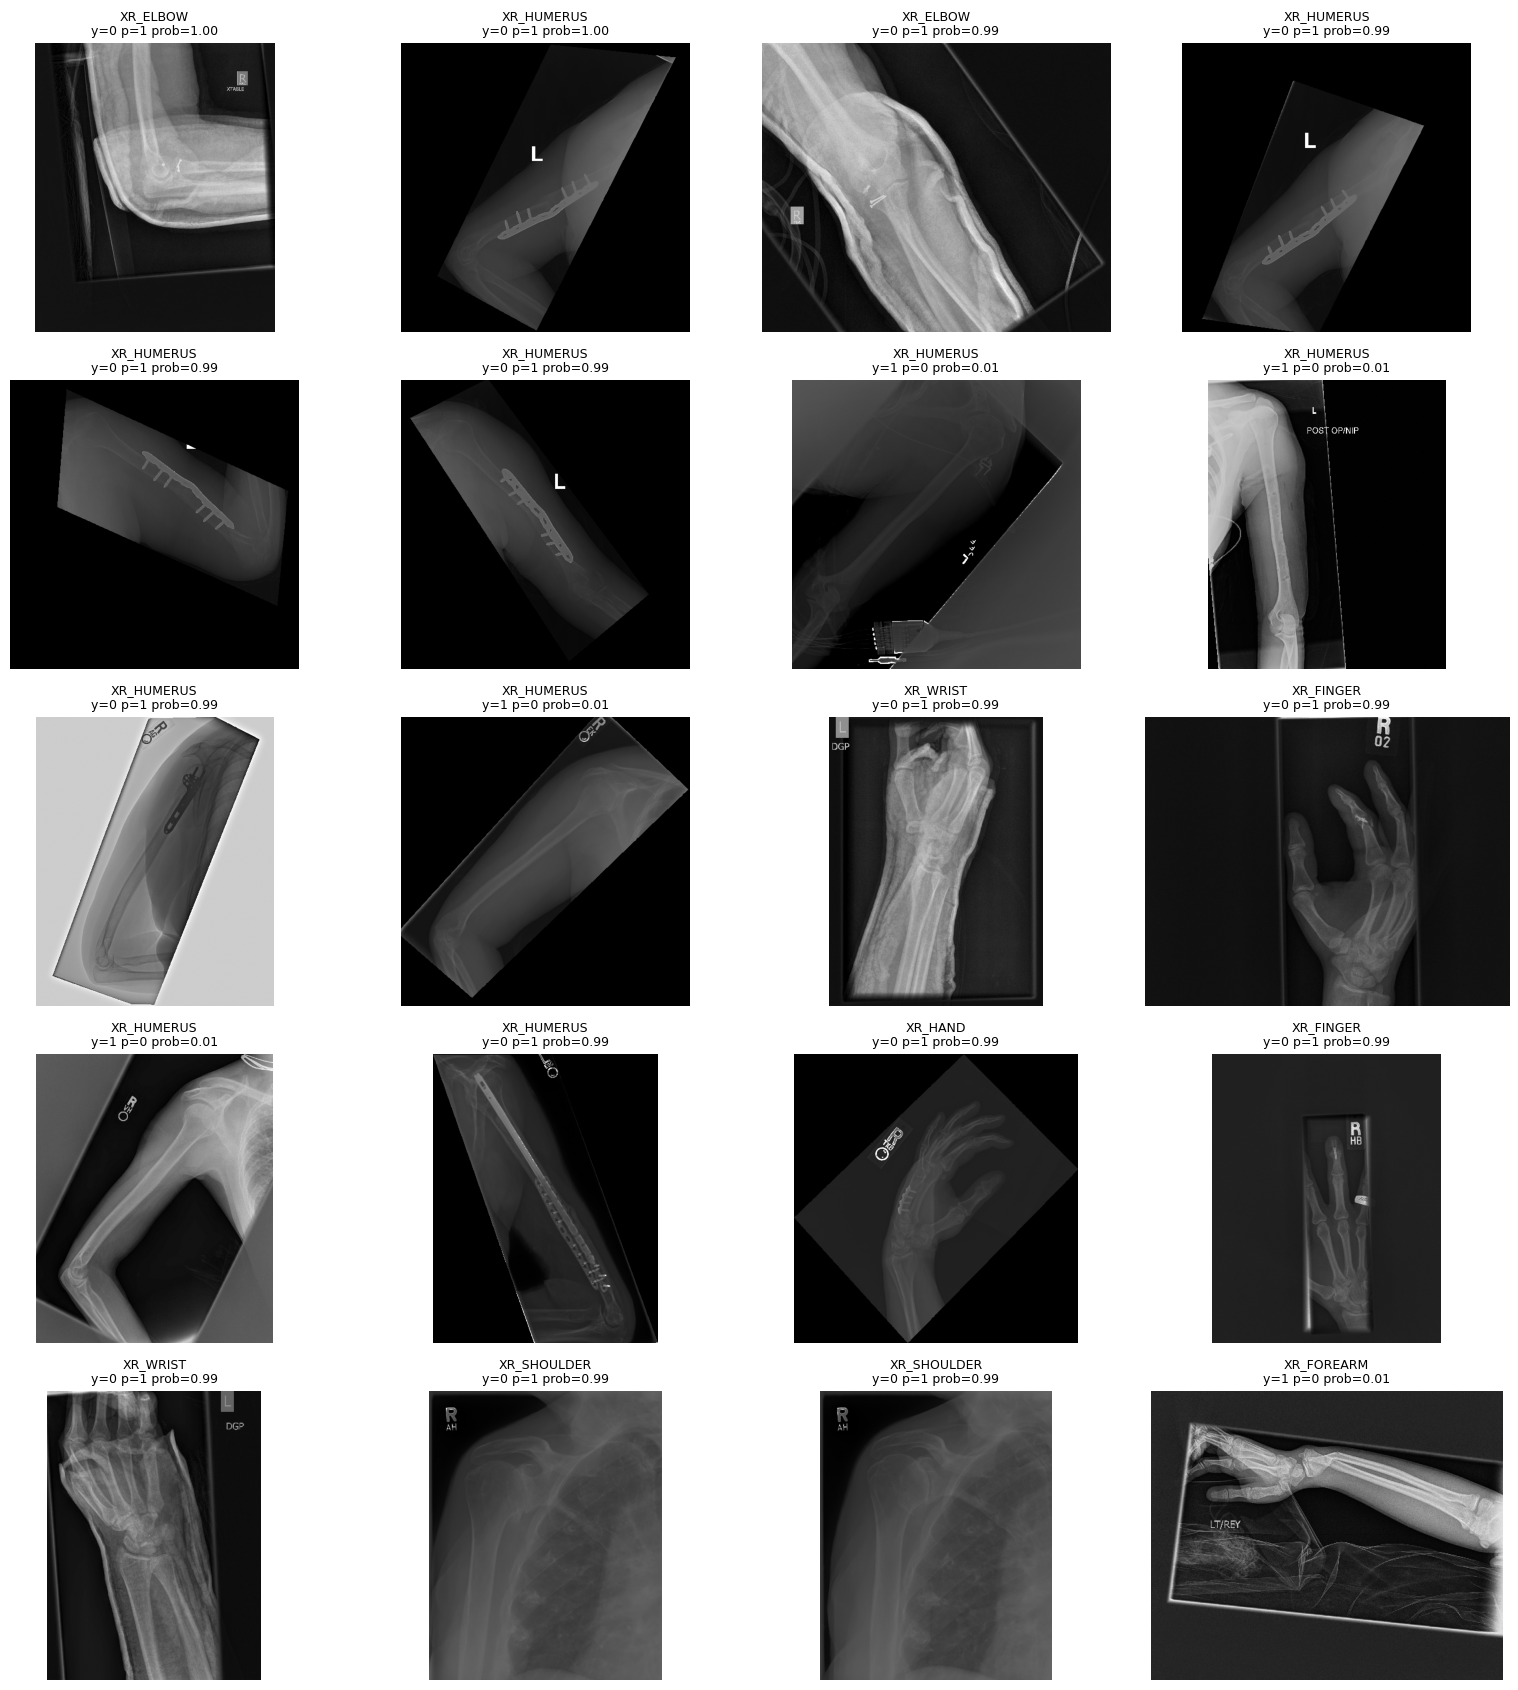

# Error analysis

Model: `facebook/dinov2-large`
Threshold selected on internal validation study-level predictions: `0.510`.

## Typical categories

1. False negatives: abnormal studies/images predicted as normal. These are usually the most clinically expensive errors.
2. False positives: normal images predicted as abnormal. These often happen when positioning, contrast, growth plates, implants, or acquisition artifacts resemble abnormal texture.
3. Near-threshold errors: probability is close to the chosen threshold, so a small perturbation can flip the prediction.
4. High-confidence errors: likely candidates for manual inspection; without radiologist annotations or bounding boxes we cannot know whether the image label, study aggregation, or model attention is the root cause.

## Why most corrections are not automatic

MURA provides study-level abnormal/normal labels inferred from folder names, not lesion locations or radiologist explanations. For a single image inside a multi-image st

,anatomy,error_type,n
0,XR_ELBOW,false_negative,38
1,XR_ELBOW,false_positive,26
2,XR_FINGER,false_negative,62
3,XR_FINGER,false_positive,30
4,XR_FOREARM,false_negative,33
5,XR_FOREARM,false_positive,7
6,XR_HAND,false_negative,58
7,XR_HAND,false_positive,26
8,XR_HUMERUS,false_negative,9
9,XR_HUMERUS,false_positive,27


In [14]:
# Error analysis: save 10-20 concrete wrong examples and a short markdown report.
test_errors = test_pred_img.copy()
test_errors["pred"] = (test_errors.prob >= best_threshold).astype(int)
test_errors = test_errors[test_errors.pred != test_errors.label].copy()
test_errors["error_type"] = np.where(test_errors.label == 1, "false_negative", "false_positive")
test_errors["confidence"] = np.where(test_errors.pred == 1, test_errors.prob, 1 - test_errors.prob)
test_errors["margin_to_threshold"] = (test_errors.prob - best_threshold).abs()
test_errors = test_errors.sort_values(["confidence", "margin_to_threshold"], ascending=[False, True])
error_sample = test_errors.head(ERROR_EXAMPLES).copy()
error_sample.to_csv(ARTIFACT_DIR / "error_examples_10_20.csv", index=False)
test_errors.to_csv(ARTIFACT_DIR / "all_test_errors.csv", index=False)

fig_cols = 4
fig_rows = max(1, math.ceil(len(error_sample) / fig_cols))
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(4 * fig_cols, 3.4 * fig_rows))
axes = np.array(axes).reshape(-1)
for ax, (_, row) in zip(axes, error_sample.iterrows()):
    img = Image.open(row.path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row.anatomy}\ny={row.label} p={row.pred} prob={row.prob:.2f}", fontsize=9)
    ax.axis("off")
for ax in axes[len(error_sample):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(ARTIFACT_DIR / "error_examples_grid.png", dpi=160, bbox_inches="tight")
plt.show()

error_counts = test_errors.groupby(["anatomy", "error_type"]).size().reset_index(name="n")
error_counts.to_csv(ARTIFACT_DIR / "error_counts_by_anatomy.csv", index=False)

error_md = f"""
# Error analysis

Model: `{HF_MODEL_NAME}`
Threshold selected on internal validation study-level predictions: `{best_threshold:.3f}`.

## Typical categories

1. False negatives: abnormal studies/images predicted as normal. These are usually the most clinically expensive errors.
2. False positives: normal images predicted as abnormal. These often happen when positioning, contrast, growth plates, implants, or acquisition artifacts resemble abnormal texture.
3. Near-threshold errors: probability is close to the chosen threshold, so a small perturbation can flip the prediction.
4. High-confidence errors: likely candidates for manual inspection; without radiologist annotations or bounding boxes we cannot know whether the image label, study aggregation, or model attention is the root cause.

## Why most corrections are not automatic

MURA provides study-level abnormal/normal labels inferred from folder names, not lesion locations or radiologist explanations. For a single image inside a multi-image study, the study label can be positive even when the visible image is not the one that contains the abnormality. Correcting such examples requires manual radiology review or richer annotations. The notebook therefore saves concrete examples for review instead of silently relabeling them.

## Saved files

- `error_examples_10_20.csv`: selected concrete wrong predictions.
- `error_examples_grid.png`: visual grid of selected wrong predictions.
- `all_test_errors.csv`: all wrong image-level predictions.
- `error_counts_by_anatomy.csv`: grouped error counts.
""".strip()
(ARTIFACT_DIR / "error_analysis.md").write_text(error_md, encoding="utf-8")
print(error_md)
display(error_counts)


In [15]:
# Robustness: perturb a bounded test subset and measure probability drift / prediction flips.
def perturb_image(image: Image.Image, kind: str) -> Image.Image:
    image = image.convert("L")
    if kind == "identity":
        return image
    if kind == "brightness_up":
        return ImageEnhance.Brightness(image).enhance(1.10)
    if kind == "brightness_down":
        return ImageEnhance.Brightness(image).enhance(0.90)
    if kind == "contrast_up":
        return ImageEnhance.Contrast(image).enhance(1.15)
    if kind == "rotate_pos5":
        return image.rotate(5, resample=Image.BICUBIC, fillcolor=0)
    if kind == "rotate_neg5":
        return image.rotate(-5, resample=Image.BICUBIC, fillcolor=0)
    if kind == "blur":
        return image.filter(ImageFilter.GaussianBlur(radius=0.8))
    raise ValueError(kind)

class RobustnessDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, kind: str):
        self.frame = frame.reset_index(drop=True)
        self.kind = kind

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row.path)
        image = perturb_image(image, self.kind)
        image = eval_transform(image)
        return image, torch.tensor(int(row.label), dtype=torch.long), row.anatomy, row.study

robust_frame = test_df.sample(n=min(ROBUSTNESS_MAX_IMAGES, len(test_df)), random_state=SEED).reset_index(drop=True)
robust_kinds = ["identity", "brightness_up", "brightness_down", "contrast_up", "rotate_pos5", "rotate_neg5", "blur"]
robust_predictions = {}
for kind in robust_kinds:
    loader = DataLoader(RobustnessDataset(robust_frame, kind), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    pred = predict_frame(model, robust_frame, loader, f"robust_{kind}")
    robust_predictions[kind] = pred[["path", "label", "anatomy", "study", "prob"]].rename(columns={"prob": f"prob_{kind}"})

robust_df = robust_predictions["identity"]
for kind in robust_kinds[1:]:
    robust_df = robust_df.merge(robust_predictions[kind][["path", f"prob_{kind}"]], on="path", how="left")

identity_pred = (robust_df.prob_identity >= best_threshold).astype(int)
robust_rows = []
for kind in robust_kinds[1:]:
    pred_kind = (robust_df[f"prob_{kind}"] >= best_threshold).astype(int)
    delta = robust_df[f"prob_{kind}"] - robust_df.prob_identity
    robust_rows.append({
        "perturbation": kind,
        "n": len(robust_df),
        "mean_abs_delta_prob": float(delta.abs().mean()),
        "max_abs_delta_prob": float(delta.abs().max()),
        "flip_rate": float((pred_kind != identity_pred).mean()),
    })
robust_report_df = pd.DataFrame(robust_rows)
robust_report_df.to_csv(ARTIFACT_DIR / "robustness_report.csv", index=False)
robust_df.to_csv(ARTIFACT_DIR / "robustness_predictions.csv", index=False)
display(robust_report_df)


predict robust_identity:   0%|          | 0/16 [00:00<?, ?it/s]

predict robust_brightness_up:   0%|          | 0/16 [00:00<?, ?it/s]

predict robust_brightness_down:   0%|          | 0/16 [00:00<?, ?it/s]

predict robust_contrast_up:   0%|          | 0/16 [00:00<?, ?it/s]

predict robust_rotate_pos5:   0%|          | 0/16 [00:00<?, ?it/s]

predict robust_rotate_neg5:   0%|          | 0/16 [00:00<?, ?it/s]

predict robust_blur:   0%|          | 0/16 [00:00<?, ?it/s]

,perturbation,n,mean_abs_delta_prob,max_abs_delta_prob,flip_rate
0,brightness_up,512,0.016576,0.257541,0.017578
1,brightness_down,512,0.016925,0.370819,0.017578
2,contrast_up,512,0.022863,0.425943,0.021484
3,rotate_pos5,512,0.049721,0.613835,0.041016
4,rotate_neg5,512,0.053945,0.838537,0.042969
5,blur,512,0.034086,0.405027,0.025391


In [16]:
# Log final artifacts and register a PRD pyfunc model.
class MuraDinoPyFunc(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        import torch
        import torch.nn as nn
        import pandas as pd
        from PIL import Image
        from torchvision import transforms
        from transformers import AutoModel

        class _SquarePadResize:
            def __init__(self, size: int, fill: int = 0):
                self.size = size
                self.fill = fill

            def __call__(self, image):
                image = image.convert("RGB")
                w, h = image.size
                scale = self.size / max(w, h)
                new_w = max(1, int(round(w * scale)))
                new_h = max(1, int(round(h * scale)))
                image = image.resize((new_w, new_h), Image.BICUBIC)
                canvas = Image.new("RGB", (self.size, self.size), color=(self.fill, self.fill, self.fill))
                canvas.paste(image, ((self.size - new_w) // 2, (self.size - new_h) // 2))
                return canvas

        class _MuraDinoClassifier(nn.Module):
            def __init__(self, model_name: str, bone_categories: list[str]):
                super().__init__()
                self.bone_categories = list(bone_categories)
                self.dino = AutoModel.from_pretrained(model_name)
                hidden_size = int(self.dino.config.hidden_size)
                self.head = nn.Sequential(
                    nn.Linear(hidden_size * 2, 512),
                    nn.LayerNorm(512),
                    nn.GELU(),
                    nn.Dropout(0.30),
                    nn.Linear(512, 128),
                    nn.GELU(),
                    nn.Dropout(0.20),
                )
                self.classifiers = nn.ModuleDict({bone: nn.Linear(128, 2) for bone in self.bone_categories})

            def forward(self, x, anatomies):
                outputs = self.dino(pixel_values=x)
                tokens = outputs.last_hidden_state
                features = self.head(torch.cat([tokens[:, 0, :], tokens[:, 1:, :].mean(dim=1)], dim=1))
                logits = torch.empty((x.size(0), 2), dtype=features.dtype, device=features.device)
                anatomies = list(anatomies)
                for bone in sorted(set(anatomies)):
                    idx = [i for i, value in enumerate(anatomies) if value == bone]
                    idx_t = torch.tensor(idx, dtype=torch.long, device=features.device)
                    logits[idx_t] = self.classifiers[bone](features[idx_t])
                return logits

        self.torch = torch
        self.pd = pd
        self.Image = Image
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        checkpoint = torch.load(context.artifacts["checkpoint"], map_location=self.device)
        cfg = checkpoint["config"]
        self.threshold = float(checkpoint.get("threshold", 0.5))
        self.transform = transforms.Compose([
            _SquarePadResize(int(cfg["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.model = _MuraDinoClassifier(cfg["hf_model_name"], cfg["bone_categories"]).to(self.device)
        self.model.load_state_dict(checkpoint["model_state"])
        self.model.eval()

    def predict(self, context, model_input):
        if not isinstance(model_input, self.pd.DataFrame):
            model_input = self.pd.DataFrame(model_input)
        required = {"image_path", "anatomy"}
        missing = required - set(model_input.columns)
        if missing:
            raise ValueError(f"Missing columns: {sorted(missing)}")
        images = []
        anatomies = []
        for _, row in model_input.iterrows():
            image = self.Image.open(row["image_path"]).convert("L")
            images.append(self.transform(image))
            anatomies.append(str(row["anatomy"]))
        batch = self.torch.stack(images).to(self.device)
        with self.torch.inference_mode():
            logits = self.model(batch, anatomies)
            probs = self.torch.softmax(logits.float(), dim=1)[:, 1].detach().cpu().numpy()
        return self.pd.DataFrame({
            "probability": probs,
            "prediction": (probs >= self.threshold).astype(int),
            "threshold": self.threshold,
        })

inference_ckpt_path = CHECKPOINT_DIR / "inference_prd.pt"
ckpt_for_inference = torch.load(best_ckpt_path, map_location=DEVICE) if best_ckpt_path.exists() else {
    "model_state": model.state_dict(),
    "config": training_config(),
}
ckpt_for_inference["model_state"] = model.state_dict()
ckpt_for_inference["threshold"] = float(best_threshold)
ckpt_for_inference["config"] = training_config()
torch.save(ckpt_for_inference, inference_ckpt_path)

sample_input = pd.DataFrame({
    "image_path": [str(test_df.path.iloc[0])],
    "anatomy": [str(test_df.anatomy.iloc[0])],
})
signature = infer_signature(sample_input, pd.DataFrame({"probability": [0.5], "prediction": [1], "threshold": [best_threshold]}))

with mlflow.start_run(run_id=RUN_ID) if RUN_ID else mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=RUN_NAME + "_register"):
    mlflow.set_tags({"env": "PRD", "registered_model": REGISTERED_MODEL_NAME})
    test_study_metric_row = final_metrics_df[
        (final_metrics_df["split"] == "test")
        & (final_metrics_df["level"] == "study")
        & (final_metrics_df["anatomy"].isna())
    ].iloc[0]
    mlflow.log_metrics({
        "final/test_study_kappa": float(test_study_metric_row["kappa"]),
        "final/test_study_accuracy": float(test_study_metric_row["accuracy"]),
        "final/best_threshold": float(best_threshold),
    })
    mlflow.log_artifacts(str(ARTIFACT_DIR), artifact_path="final_artifacts")
    mlflow.log_artifact(str(inference_ckpt_path), artifact_path="checkpoints")
    model_info = mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=MuraDinoPyFunc(),
        artifacts={"checkpoint": str(inference_ckpt_path)},
        registered_model_name=REGISTERED_MODEL_NAME,
        signature=signature,
        input_example=sample_input,
        pip_requirements=[
            "mlflow>=2.15.1,<3",
            "torch",
            "torchvision",
            "transformers>=4.45",
            "pandas",
            "numpy",
            "pillow",
        ],
    )
    version = model_info.registered_model_version
    client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "env", "PRD")
    client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "source", "MURA-v1.1.zip")
    client.set_registered_model_alias(REGISTERED_MODEL_NAME, "prd", version)
    print("registered model:", REGISTERED_MODEL_NAME)
    print("version:", version)
    print("alias: prd")

loaded = mlflow.pyfunc.load_model(f"models:/{REGISTERED_MODEL_NAME}@prd")
print(loaded.predict(sample_input))


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/doc

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

2026/06/01 19:19:22 INFO mlflow.pyfunc: Validating input example against model signature


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Successfully registered model 'mura_dinov2_transformer'.
2026/06/01 19:27:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mura_dinov2_transformer, version 1
Created version '1' of model 'mura_dinov2_transformer'.


registered model: mura_dinov2_transformer
version: 1
alias: prd
🏃 View run dinov2_transformer_raw_mura at: http://64.226.117.149:8094/#/experiments/1/runs/881e12663a1f47ad92782a3747339baa
🧪 View experiment at: http://64.226.117.149:8094/#/experiments/1


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

   probability  prediction  threshold
0     0.996223           1       0.51
